# 02 - Experimentos de Modelagem

Split estratificado, feature selection, PCA, treinamento e comparacao de modelos. O modelo final e persistido em `models/`.

## Roteiro

1. Carregar `dataset_3_doencas.csv`
2. Split treino / validacao / teste estratificado
3. Baseline sem selecao de features (F2.1)
4. Feature Selection: VarianceThreshold + SelectKBest chi2 + mutual_info (F2.2)
5. PCA como alternativa (F2.3)
6. Modelo A — Regressao Logistica com GridSearchCV (F3.1)
7. Modelo B — Random Forest com GridSearchCV (F3.2)
8. Comparacao e selecao do modelo final (F3.3)
9. Avaliacao no conjunto de teste (F4)
10. Persistencia em models/

In [1]:
import json
import sys
import gc
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, VarianceThreshold, chi2, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    log_loss,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore', category=UserWarning)

project_root = Path.cwd()
for _ in range(4):
    if (project_root / 'src').is_dir() and (project_root / 'data').is_dir():
        break
    project_root = project_root.parent
else:
    raise FileNotFoundError('Raiz do projeto nao encontrada.')

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.utils import (
    CLASSES_ALVO,
    FILTERED_DATA_PATH,
    MODELS_DIR,
    RANDOM_STATE,
    evaluate_model,
    plot_confusion_matrix,
    split_data,
)

print(f'sklearn: {sklearn.__version__}')
print(f'Classes alvo: {CLASSES_ALVO}')
print(f'Projeto em: {project_root}')

sklearn: 1.7.2
Classes alvo: ('pneumonia', 'gout', 'anxiety')
Projeto em: C:\Users\felip\GitHub\machine-learning-project


## 1. Carregar dataset filtrado

In [2]:
df = pd.read_csv(FILTERED_DATA_PATH)
df['diseases'] = df['diseases'].astype(str).str.strip()

print(f'Shape: {df.shape}')
print(f'\nDistribuicao das classes:')
print(df['diseases'].value_counts())
print(f'\nColunas de features: {df.shape[1] - 1}')

Shape: (3621, 35)

Distribuicao das classes:
diseases
pneumonia    1212
gout         1211
anxiety      1198
Name: count, dtype: int64

Colunas de features: 34


## 2. Split estratificado

In [3]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(
    df,
    test_size=0.2,
    val_size=0.1,
    random_state=RANDOM_STATE,
)

print(f'Treino:    {X_train.shape[0]} amostras')
print(f'Validacao: {X_val.shape[0]} amostras')
print(f'Teste:     {X_test.shape[0]} amostras')

print('\nDistribuicao por split:')
for nome, y in [('Treino', y_train), ('Validacao', y_val), ('Teste', y_test)]:
    dist = y.value_counts(normalize=True).round(3)
    print(f'  {nome}: {dict(dist)}')

Treino:    2534 amostras
Validacao: 362 amostras
Teste:     725 amostras

Distribuicao por split:
  Treino: {'pneumonia': np.float64(0.335), 'gout': np.float64(0.335), 'anxiety': np.float64(0.331)}
  Validacao: {'gout': np.float64(0.334), 'pneumonia': np.float64(0.334), 'anxiety': np.float64(0.331)}
  Teste: {'pneumonia': np.float64(0.335), 'gout': np.float64(0.334), 'anxiety': np.float64(0.331)}


## 3. Baseline sem selecao de features (F2.1)

In [4]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_val)

metrics_dummy = evaluate_model(y_val, y_pred_dummy, labels=list(CLASSES_ALVO))

print('=== BASELINE (DummyClassifier most_frequent) ===')
print(f"Accuracy:        {metrics_dummy['accuracy']:.4f}")
print(f"F1-macro:        {metrics_dummy['f1_macro']:.4f}")
print(f"Precision-macro: {metrics_dummy['precision_macro']:.4f}")
print(f"Recall-macro:    {metrics_dummy['recall_macro']:.4f}")

=== BASELINE (DummyClassifier most_frequent) ===
Accuracy:        0.3343
F1-macro:        0.1670
Precision-macro: 0.1114
Recall-macro:    0.3333


In [5]:
lr_baseline = LogisticRegression(
    solver='lbfgs', max_iter=1000, random_state=RANDOM_STATE
)
lr_baseline.fit(X_train, y_train)
y_pred_lr_base = lr_baseline.predict(X_val)

metrics_lr_base = evaluate_model(y_val, y_pred_lr_base, labels=list(CLASSES_ALVO))

print('=== BASELINE — Regressao Logistica (todas as features) ===')
print(f"Accuracy:        {metrics_lr_base['accuracy']:.4f}")
print(f"F1-macro:        {metrics_lr_base['f1_macro']:.4f}")
print(f"Features usadas: {X_train.shape[1]}")

=== BASELINE — Regressao Logistica (todas as features) ===
Accuracy:        1.0000
F1-macro:        1.0000
Features usadas: 34


## 4. Feature Selection (F2.2)

### 4.1 VarianceThreshold

In [6]:
vt = VarianceThreshold(threshold=0.0)
vt.fit(X_train)
mask_vt = vt.get_support()

X_train_vt = X_train.loc[:, mask_vt]
X_val_vt   = X_val.loc[:, mask_vt]
X_test_vt  = X_test.loc[:, mask_vt]

print(f'Features antes: {X_train.shape[1]}')
print(f'Features apos VarianceThreshold: {X_train_vt.shape[1]}')
print(f'Removidas: {X_train.shape[1] - X_train_vt.shape[1]}')

Features antes: 34


Features apos VarianceThreshold: 34
Removidas: 0


### 4.2 SelectKBest chi2

In [7]:
K_BEST = min(25, X_train_vt.shape[1])

selector_chi2 = SelectKBest(chi2, k=K_BEST)
selector_chi2.fit(X_train_vt, y_train)

selected_chi2 = X_train_vt.columns[selector_chi2.get_support()].tolist()

X_train_chi2 = selector_chi2.transform(X_train_vt)
X_val_chi2   = selector_chi2.transform(X_val_vt)
X_test_chi2  = selector_chi2.transform(X_test_vt)

print(f'Features selecionadas por chi2 (K={K_BEST}):')
for f in selected_chi2:
    print(f'  {f}')

Features selecionadas por chi2 (K=25):
  anxiety and nervousness
  depression
  depressive or psychotic symptoms
  insomnia
  abnormal involuntary movements
  palpitations
  irregular heartbeat
  sore throat
  nasal congestion
  vomiting
  headache
  wrist pain
  hand or finger swelling
  knee pain
  foot or toe pain
  ankle pain
  knee swelling
  foot or toe swelling
  weakness
  difficulty breathing
  joint pain
  chills
  coryza
  fears and phobias
  ankle swelling


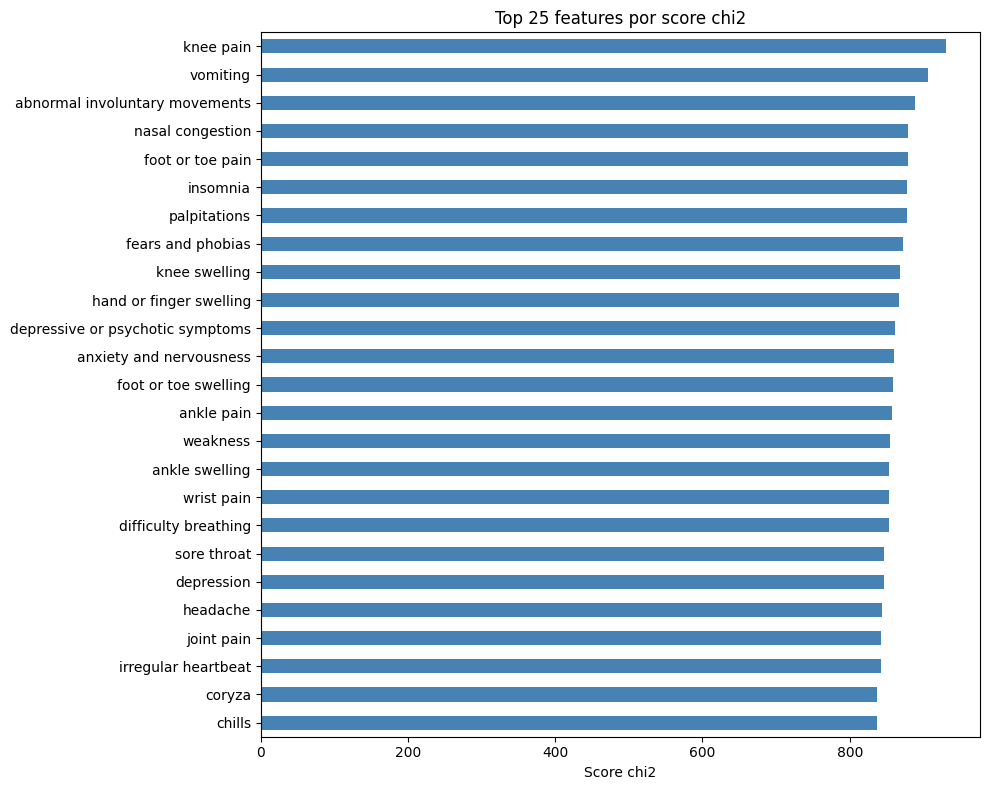

In [8]:
scores_chi2 = pd.Series(
    selector_chi2.scores_[selector_chi2.get_support()],
    index=selected_chi2,
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
scores_chi2.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Score chi2')
ax.set_title(f'Top {K_BEST} features por score chi2')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(project_root / 'data' / 'figs' / 'chi2_scores.png', dpi=100)
plt.show()

### 4.3 Mutual Information

In [9]:
mi_scores = mutual_info_classif(
    X_train_vt, y_train, discrete_features=True, random_state=RANDOM_STATE
)
mi_series = pd.Series(mi_scores, index=X_train_vt.columns).sort_values(ascending=False)

selector_mi = SelectKBest(mutual_info_classif, k=K_BEST)
selector_mi.fit(X_train_vt, y_train)

X_train_mi = selector_mi.transform(X_train_vt)
X_val_mi   = selector_mi.transform(X_val_vt)
X_test_mi  = selector_mi.transform(X_test_vt)

print('Top 20 features por Mutual Information:')
print(mi_series.head(20).round(4).to_string())

Top 20 features por Mutual Information:
knee pain                           0.2483
vomiting                            0.2403
abnormal involuntary movements      0.2321
nasal congestion                    0.2312
foot or toe pain                    0.2312
insomnia                            0.2289
palpitations                        0.2289
knee swelling                       0.2280
hand or finger swelling             0.2273
fears and phobias                   0.2269
foot or toe swelling                0.2247
ankle pain                          0.2241
depressive or psychotic symptoms    0.2237
weakness                            0.2235
anxiety and nervousness             0.2231
ankle swelling                      0.2228
difficulty breathing                0.2228
wrist pain                          0.2228
sore throat                         0.2209
joint pain                          0.2197


In [10]:
results_fs = {}
for nome, Xtr, Xvl in [
    ('Todas as features',  X_train,      X_val),
    ('VarianceThreshold',  X_train_vt,   X_val_vt),
    ('SelectKBest chi2',   X_train_chi2, X_val_chi2),
    ('Mutual Info',        X_train_mi,   X_val_mi),
]:
    lr = LogisticRegression(
        solver='lbfgs', max_iter=1000, random_state=RANDOM_STATE
    )
    lr.fit(Xtr, y_train)
    ypred = lr.predict(Xvl)
    m = evaluate_model(y_val, ypred, labels=list(CLASSES_ALVO))
    results_fs[nome] = {
        'n_features': Xtr.shape[1],
        'accuracy':   round(m['accuracy'], 4),
        'f1_macro':   round(m['f1_macro'], 4),
    }

df_fs = pd.DataFrame(results_fs).T
print('=== COMPARACAO — Feature Selection ===')
print(df_fs.to_string())

=== COMPARACAO — Feature Selection ===


                   n_features  accuracy  f1_macro
Todas as features        34.0       1.0       1.0
VarianceThreshold        34.0       1.0       1.0
SelectKBest chi2         25.0       1.0       1.0
Mutual Info              25.0       1.0       1.0


## 5. PCA comparativo (F2.3)

Variancia explicada (20 comp.): 0.783


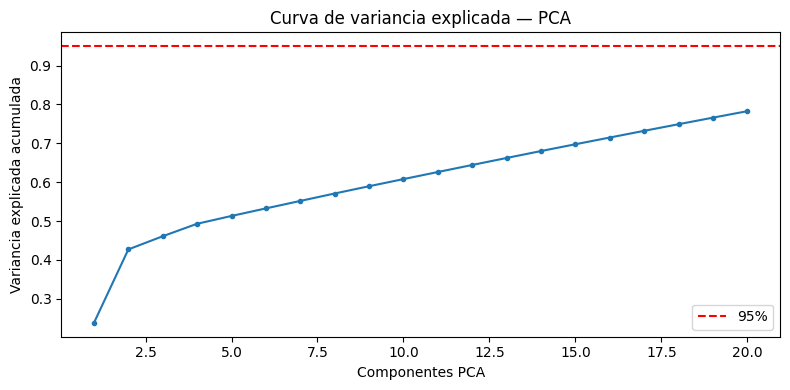

LR + PCA — F1-macro: 1.0000 | Accuracy: 1.0000


In [11]:
N_COMPONENTS = min(20, X_train_vt.shape[1])

pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_vt)
X_val_pca   = pca.transform(X_val_vt)
X_test_pca  = pca.transform(X_test_vt)

explained = pca.explained_variance_ratio_.cumsum()
print(f'Variancia explicada ({N_COMPONENTS} comp.): {explained[-1]:.3f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, N_COMPONENTS + 1), explained, marker='o', markersize=3)
ax.axhline(0.95, color='red', linestyle='--', label='95%')
ax.set_xlabel('Componentes PCA')
ax.set_ylabel('Variancia explicada acumulada')
ax.set_title('Curva de variancia explicada — PCA')
ax.legend()
plt.tight_layout()
plt.savefig(project_root / 'data' / 'figs' / 'pca_variance.png', dpi=100)
plt.show()

lr_pca = LogisticRegression(
    solver='lbfgs', max_iter=1000, random_state=RANDOM_STATE
)
lr_pca.fit(X_train_pca, y_train)
ypred_pca = lr_pca.predict(X_val_pca)
m_pca = evaluate_model(y_val, ypred_pca, labels=list(CLASSES_ALVO))
print(f"LR + PCA — F1-macro: {m_pca['f1_macro']:.4f} | Accuracy: {m_pca['accuracy']:.4f}")

In [12]:
# Abordagem final: SelectKBest chi2
# Razao: melhor interpretabilidade que PCA; features tem significado clinico direto.
print(f'Abordagem final de features: SelectKBest chi2 com K = {K_BEST}')

Abordagem final de features: SelectKBest chi2 com K = 25


## 6. Treinamento dos modelos (F3.1 e F3.2)

### 6.1 Modelo A — Regressao Logistica

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_grid_lr = {
    'C':        [0.01, 0.1, 1.0, 10.0],
    'solver':   ['lbfgs', 'saga'],
    'max_iter': [2000],
}

grid_lr = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE),
    param_grid_lr,
    cv=cv,
    scoring='f1_macro',
    n_jobs=1,
    verbose=1,
)
grid_lr.fit(X_train_chi2, y_train)

print(f'Melhor params LR: {grid_lr.best_params_}')
print(f'F1-macro CV:      {grid_lr.best_score_:.4f}')

best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_val_chi2)
metrics_lr = evaluate_model(y_val, y_pred_lr, labels=list(CLASSES_ALVO))
print(f"Validacao — F1-macro: {metrics_lr['f1_macro']:.4f} | Accuracy: {metrics_lr['accuracy']:.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits


Melhor params LR: {'C': 0.01, 'max_iter': 2000, 'solver': 'lbfgs'}
F1-macro CV:      1.0000
Validacao — F1-macro: 1.0000 | Accuracy: 1.0000


### 6.2 Modelo B — Random Forest

In [14]:
param_grid_rf = {
    'n_estimators':   [100, 200],
    'max_depth':      [None, 20, 40],
    'min_samples_leaf': [1, 3],
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid_rf,
    cv=cv,
    scoring='f1_macro',
    n_jobs=1,
    verbose=1,
)
grid_rf.fit(X_train_chi2, y_train)

print(f'Melhor params RF: {grid_rf.best_params_}')
print(f'F1-macro CV:      {grid_rf.best_score_:.4f}')

best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_val_chi2)
metrics_rf = evaluate_model(y_val, y_pred_rf, labels=list(CLASSES_ALVO))
print(f"Validacao — F1-macro: {metrics_rf['f1_macro']:.4f} | Accuracy: {metrics_rf['accuracy']:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits


Melhor params RF: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}
F1-macro CV:      1.0000
Validacao — F1-macro: 1.0000 | Accuracy: 1.0000


## 7. Comparacao e selecao do modelo final (F3.3)

In [15]:
df_compare = pd.DataFrame({
    'Baseline (Dummy)':    metrics_dummy,
    'Regressao Logistica': metrics_lr,
    'Random Forest':       metrics_rf,
}).T[['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']]

print('=== COMPARACAO FINAL — Validacao ===')
print(df_compare.round(4).to_string())

melhor = df_compare['f1_macro'].idxmax()
print(f'\nModelo vencedor: {melhor}')

=== COMPARACAO FINAL — Validacao ===
                     accuracy  f1_macro precision_macro recall_macro
Baseline (Dummy)     0.334254  0.167012        0.111418     0.333333
Regressao Logistica       1.0       1.0             1.0          1.0
Random Forest             1.0       1.0             1.0          1.0

Modelo vencedor: Regressao Logistica


In [16]:
if melhor == 'Random Forest':
    final_model = best_rf
    NOME_MODELO = 'random_forest'
else:
    final_model = best_lr
    NOME_MODELO = 'logistic_regression'

FEATURES_USADAS = selected_chi2
print(f'Modelo final: {NOME_MODELO}')
print(f'Features:     {len(FEATURES_USADAS)}')

Modelo final: logistic_regression
Features:     25


## 8. Avaliacao no conjunto de TESTE (F4)

> O conjunto de teste e usado **uma unica vez** aqui, apos o modelo ja ter sido escolhido. Nao deve ser usado em etapas anteriores.

In [17]:
X_test_final = X_test_chi2
y_pred_test  = final_model.predict(X_test_final)
metrics_test = evaluate_model(y_test, y_pred_test, labels=list(CLASSES_ALVO))

print('=== AVALIACAO FINAL — Conjunto de Teste ===')
print(f"Accuracy:        {metrics_test['accuracy']:.4f}")
print(f"F1-macro:        {metrics_test['f1_macro']:.4f}")
print(f"Precision-macro: {metrics_test['precision_macro']:.4f}")
print(f"Recall-macro:    {metrics_test['recall_macro']:.4f}")
print('\nClassification Report:')
print(metrics_test['classification_report'].round(4).to_string())

=== AVALIACAO FINAL — Conjunto de Teste ===
Accuracy:        0.9986
F1-macro:        0.9986
Precision-macro: 0.9986
Recall-macro:    0.9986

Classification Report:
              precision  recall  f1-score   support
pneumonia        0.9959  1.0000    0.9979  243.0000
gout             1.0000  1.0000    1.0000  242.0000
anxiety          1.0000  0.9958    0.9979  240.0000
accuracy         0.9986  0.9986    0.9986    0.9986
macro avg        0.9986  0.9986    0.9986  725.0000
weighted avg     0.9986  0.9986    0.9986  725.0000


### 8.1 Matriz de confusao

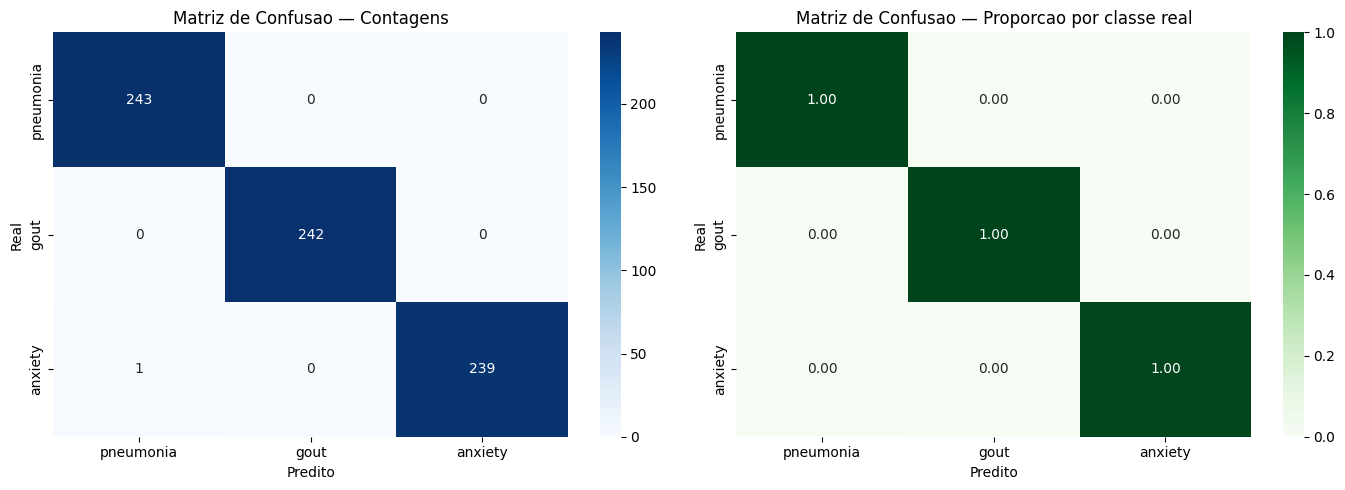

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_confusion_matrix(y_test, y_pred_test, labels=list(CLASSES_ALVO), ax=axes[0])
axes[0].set_title('Matriz de Confusao — Contagens')

plot_confusion_matrix(
    y_test, y_pred_test, labels=list(CLASSES_ALVO),
    normalize='true', ax=axes[1], cmap='Greens'
)
axes[1].set_title('Matriz de Confusao — Proporcao por classe real')

plt.tight_layout()
plt.savefig(project_root / 'data' / 'figs' / 'confusion_matrix.png', dpi=100)
plt.show()

### 8.2 ROC-AUC e Curvas Precision-Recall

ROC-AUC macro (OvR): 1.0000


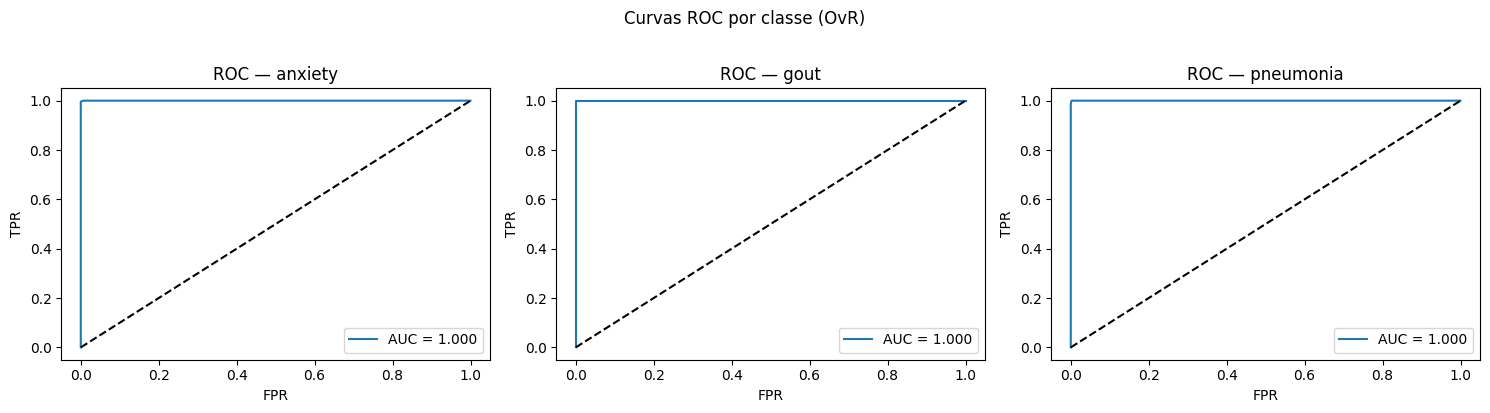

In [19]:
label_list = list(final_model.classes_)
y_test_bin = label_binarize(y_test, classes=label_list)
y_proba    = final_model.predict_proba(X_test_final)

roc_auc = roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr')
print(f'ROC-AUC macro (OvR): {roc_auc:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, cls in enumerate(label_list):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    auc_cls = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    axes[i].plot(fpr, tpr, label=f'AUC = {auc_cls:.3f}')
    axes[i].plot([0, 1], [0, 1], 'k--')
    axes[i].set_xlabel('FPR')
    axes[i].set_ylabel('TPR')
    axes[i].set_title(f'ROC — {cls}')
    axes[i].legend()

plt.suptitle('Curvas ROC por classe (OvR)', y=1.02)
plt.tight_layout()
plt.savefig(project_root / 'data' / 'figs' / 'roc_curves.png', dpi=100)
plt.show()

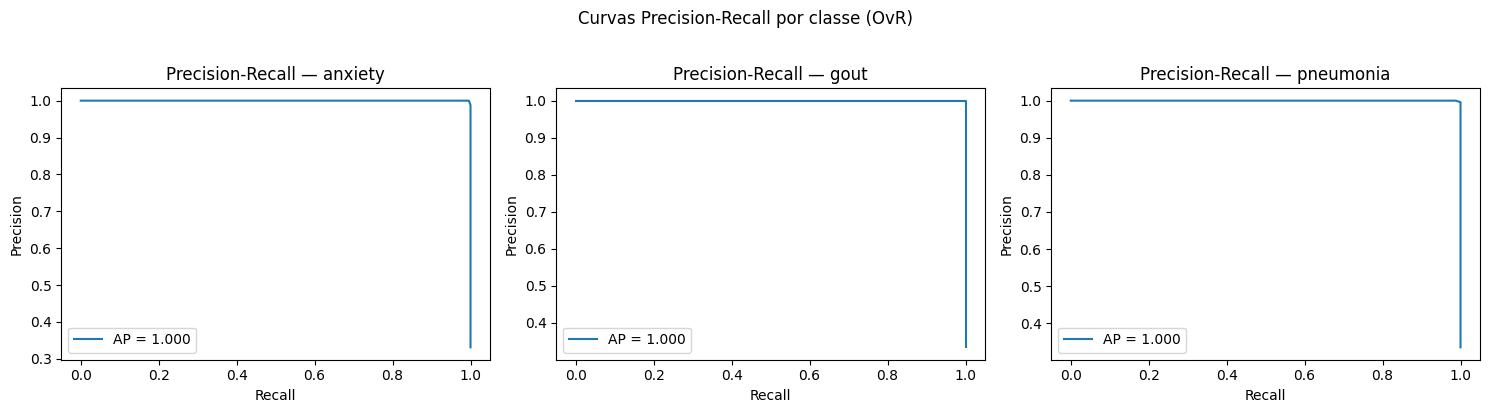

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, cls in enumerate(label_list):
    prec, rec, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_proba[:, i])
    axes[i].plot(rec, prec, label=f'AP = {ap:.3f}')
    axes[i].set_xlabel('Recall')
    axes[i].set_ylabel('Precision')
    axes[i].set_title(f'Precision-Recall — {cls}')
    axes[i].legend()

plt.suptitle('Curvas Precision-Recall por classe (OvR)', y=1.02)
plt.tight_layout()
plt.savefig(project_root / 'data' / 'figs' / 'pr_curves.png', dpi=100)
plt.show()

In [21]:
ll = log_loss(y_test, y_proba, labels=label_list)
print(f'Log-Loss no teste: {ll:.4f}')
print('(Referencia: log-loss perfeito = 0.0, dummy ~ ln(3) ~ 1.099)')

Log-Loss no teste: 0.1637
(Referencia: log-loss perfeito = 0.0, dummy ~ ln(3) ~ 1.099)


### 8.3 Analise de erros

In [22]:
X_test_df = X_test.copy()
X_test_df['y_real'] = y_test.values
X_test_df['y_pred'] = y_pred_test
erros = X_test_df[X_test_df['y_real'] != X_test_df['y_pred']]

print(f'Total de erros: {len(erros)} de {len(X_test)} ({len(erros)/len(X_test)*100:.1f}%)')
print('\nDistribuicao dos erros por par real -> predito:')
print(erros.groupby(['y_real', 'y_pred']).size().sort_values(ascending=False).to_string())

Total de erros: 1 de 725 (0.1%)

Distribuicao dos erros por par real -> predito:
y_real   y_pred   
anxiety  pneumonia    1


In [23]:
pares = erros.groupby(['y_real', 'y_pred']).size().sort_values(ascending=False)
for (real, pred), count in pares.items():
    subset = erros[(erros['y_real'] == real) & (erros['y_pred'] == pred)][FEATURES_USADAS]
    top5 = subset.mean().sort_values(ascending=False).head(5)
    print(f'\n{real} -> {pred} ({count} erros) — sintomas mais frequentes nos erros:')
    for s, v in top5.items():
        print(f'  {s}: {v:.2f}')


anxiety -> pneumonia (1 erros) — sintomas mais frequentes nos erros:
  anxiety and nervousness: 0.00
  depression: 0.00
  depressive or psychotic symptoms: 0.00
  insomnia: 0.00
  abnormal involuntary movements: 0.00


## 9. Persistencia do modelo final (models/)

In [24]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODELS_DIR / 'best_model.joblib'
joblib.dump(final_model, model_path)
print(f'Modelo salvo em: {model_path}')

selector_path = MODELS_DIR / 'feature_selector.joblib'
joblib.dump(selector_chi2, selector_path)
print(f'Selector salvo em: {selector_path}')

metadata = {
    'model':             NOME_MODELO,
    'classes':           list(final_model.classes_),
    'configured_classes': list(CLASSES_ALVO),
    'features':          FEATURES_USADAS,
    'n_features':        len(FEATURES_USADAS),
    'feature_selection': 'SelectKBest_chi2',
    'k_best':            K_BEST,
    'metrics_test': {
        'accuracy':        round(metrics_test['accuracy'], 4),
        'f1_macro':        round(metrics_test['f1_macro'], 4),
        'precision_macro': round(metrics_test['precision_macro'], 4),
        'recall_macro':    round(metrics_test['recall_macro'], 4),
        'roc_auc_macro':   round(roc_auc, 4),
        'log_loss':        round(ll, 4),
    },
    'random_state':    RANDOM_STATE,
    'sklearn_version': sklearn.__version__,
}

meta_path = MODELS_DIR / 'metadata.json'
with open(meta_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print(f'Metadata salvo em: {meta_path}')
print('\nConteudo do metadata:')
print(json.dumps(metadata, indent=2))

Modelo salvo em: C:\Users\felip\GitHub\machine-learning-project\models\best_model.joblib
Selector salvo em: C:\Users\felip\GitHub\machine-learning-project\models\feature_selector.joblib
Metadata salvo em: C:\Users\felip\GitHub\machine-learning-project\models\metadata.json

Conteudo do metadata:
{
  "model": "logistic_regression",
  "classes": [
    "anxiety",
    "gout",
    "pneumonia"
  ],
  "configured_classes": [
    "pneumonia",
    "gout",
    "anxiety"
  ],
  "features": [
    "anxiety and nervousness",
    "depression",
    "depressive or psychotic symptoms",
    "insomnia",
    "abnormal involuntary movements",
    "palpitations",
    "irregular heartbeat",
    "sore throat",
    "nasal congestion",
    "vomiting",
    "headache",
    "wrist pain",
    "hand or finger swelling",
    "knee pain",
    "foot or toe pain",
    "ankle pain",
    "knee swelling",
    "foot or toe swelling",
    "weakness",
    "difficulty breathing",
    "joint pain",
    "chills",
    "coryza",
   